# Estudo de Robustez Temporal -- Rede Neural para Regressao (SLCE3 + Base Agro)

Replica o experimento `regressao_linear_rede_neural/dataset_base/regressao_linear_rede_neural_slce3` substituindo:

- `train_test_split(shuffle=True)` por **holdout temporal** (ultimos 20% das amostras como teste)
- `KFold(shuffle=True)` por `TimeSeriesSplit(n_splits=5)`

Objetivo: quantificar o vies introduzido pela validacao aleatoria em uma serie temporal autocorrelacionada (Cap. 4, Secao 4.6 da monografia).

In [1]:
import warnings
from pathlib import Path
from typing import cast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

OUTPUT_DIR = Path('./')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

COMPANY = 'SLCE3'
DATASET_LABEL = 'base_timeseries'
company_lower = COMPANY.lower()

df = pd.read_csv('../../datasets/datasets_base/regressao/SLCE3_tratado.csv', index_col=0, parse_dates=True)
df = df.sort_index()  # garante ordem cronologica

print(f'Dataset {COMPANY} (regressao base): {df.shape}')
print(f'Periodo: {df.index.min().date()} a {df.index.max().date()}')

Dataset SLCE3 (regressao base): (1652, 17)
Periodo: 2018-01-17 a 2024-11-11


In [2]:
base_features = ['Close', 'Low', 'High', 'Open']
agro_lag_features = [
    'agro_cambio_close_lag_1d', 'agro_cambio_close_lag_3d',
    'agro_cambio_close_lag_6d', 'agro_cambio_close_lag_10d',
    'agro_soja_close_lag_1d', 'agro_soja_close_lag_3d',
    'agro_soja_close_lag_6d', 'agro_soja_close_lag_10d',
]
all_features = base_features + agro_lag_features

X = df[all_features].copy()
targets = {
    '3d': df['Close_3d_fut'],
    '7d': df['Close_7d_fut'],
    '15d': df['Close_15d_fut'],
    '30d': df['Close_30d_fut'],
}

param_dist = {
    'model__hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64)],
    'model__activation': ['relu', 'tanh'],
    'model__alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'model__learning_rate_init': [1e-4, 5e-4, 1e-3, 5e-3],
    'model__solver': ['adam', 'lbfgs'],
}

cv_strategy = TimeSeriesSplit(n_splits=5)
print('CV strategy:', cv_strategy)

CV strategy: TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


In [3]:
results = {}
for period, y in targets.items():
    print(f'\n========== Horizonte {period.upper()} ==========')
    mask = ~y.isnull()
    X_clean = X.loc[mask].copy()
    y_clean = y.loc[mask].copy()

    # Holdout TEMPORAL: ultimos 20% das amostras viram teste
    n_total = len(X_clean)
    n_test = int(round(0.2 * n_total))
    X_dev = X_clean.iloc[: n_total - n_test].copy()
    y_dev = y_clean.iloc[: n_total - n_test].copy()
    X_test = X_clean.iloc[n_total - n_test :].copy()
    y_test = y_clean.iloc[n_total - n_test :].copy()

    print(f'  Dev: {X_dev.index.min().date()} a {X_dev.index.max().date()} ({len(X_dev)} amostras)')
    print(f'  Teste: {X_test.index.min().date()} a {X_test.index.max().date()} ({len(X_test)} amostras)')

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', MLPRegressor(max_iter=1500, random_state=42)),
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist,
        n_iter=5,
        scoring='neg_mean_absolute_error',
        cv=cv_strategy,
        n_jobs=-1,
        random_state=42,
        verbose=0,
    )
    search.fit(X_dev, y_dev)
    best_pipeline = cast(Pipeline, search.best_estimator_)

    # OOF temporal manual (TimeSeriesSplit nao cobre todas as amostras como cross_val_predict)
    oof = np.full(len(y_dev), np.nan)
    for tr_idx, val_idx in cv_strategy.split(X_dev):
        clone_pipe = clone(best_pipeline)
        clone_pipe.fit(X_dev.iloc[tr_idx], y_dev.iloc[tr_idx])
        oof[val_idx] = clone_pipe.predict(X_dev.iloc[val_idx])
    mask_oof = ~np.isnan(oof)
    oof_r2 = r2_score(y_dev.iloc[mask_oof], oof[mask_oof])
    oof_mae = mean_absolute_error(y_dev.iloc[mask_oof], oof[mask_oof])

    # Refit + holdout
    best_pipeline.fit(X_dev, y_dev)
    y_pred = best_pipeline.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))

    print(f'  CV MAE (best):    {-search.best_score_:.4f}')
    print(f'  OOF R2 / MAE:     {oof_r2:.4f} / {oof_mae:.4f}')
    print(f'  Test R2 / MAE / RMSE: {test_r2:.4f} / {test_mae:.4f} / {test_rmse:.4f}')

    results[period] = {
        'cv_mae': -search.best_score_,
        'oof_r2': oof_r2,
        'oof_mae': oof_mae,
        'test_r2': test_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred,
    }


========== Horizonte 3D ==========
  Dev: 2018-01-17 a 2023-07-10 (1322 amostras)
  Teste: 2023-07-11 a 2024-11-11 (330 amostras)


  CV MAE (best):    1.2040
  OOF R2 / MAE:     0.8975 / 1.2040
  Test R2 / MAE / RMSE: 0.2934 / 0.5905 / 0.6999

========== Horizonte 7D ==========
  Dev: 2018-01-17 a 2023-07-10 (1322 amostras)
  Teste: 2023-07-11 a 2024-11-11 (330 amostras)


  CV MAE (best):    1.3067
  OOF R2 / MAE:     0.8936 / 1.3067
  Test R2 / MAE / RMSE: 0.3634 / 0.5140 / 0.6658

========== Horizonte 15D ==========
  Dev: 2018-01-17 a 2023-07-10 (1322 amostras)
  Teste: 2023-07-11 a 2024-11-11 (330 amostras)


  CV MAE (best):    1.3038
  OOF R2 / MAE:     0.8935 / 1.3038
  Test R2 / MAE / RMSE: -2.4032 / 1.1137 / 1.4216

========== Horizonte 30D ==========
  Dev: 2018-01-17 a 2023-07-10 (1322 amostras)
  Teste: 2023-07-11 a 2024-11-11 (330 amostras)


  CV MAE (best):    2.1286
  OOF R2 / MAE:     0.7258 / 2.1286
  Test R2 / MAE / RMSE: -3.9018 / 1.1759 / 1.3953


In [4]:
tabela = pd.DataFrame({
    'Horizonte': ['3 dias', '7 dias', '15 dias', '30 dias'],
    'CV MAE': [results[p]['cv_mae'] for p in ['3d', '7d', '15d', '30d']],
    'OOF R2': [results[p]['oof_r2'] for p in ['3d', '7d', '15d', '30d']],
    'OOF MAE': [results[p]['oof_mae'] for p in ['3d', '7d', '15d', '30d']],
    'Test R2': [results[p]['test_r2'] for p in ['3d', '7d', '15d', '30d']],
    'Test MAE': [results[p]['test_mae'] for p in ['3d', '7d', '15d', '30d']],
    'Test RMSE': [results[p]['test_rmse'] for p in ['3d', '7d', '15d', '30d']],
})
print('=== Resultados Rede Neural (Regressao) -- SLCE3 -- TimeSeriesSplit ===')
print(tabela.to_string(index=False))
tabela.to_csv(OUTPUT_DIR / f'metricas_{company_lower}_{DATASET_LABEL}.csv', index=False)
print(f'\nSalvo: metricas_{company_lower}_{DATASET_LABEL}.csv')

=== Resultados Rede Neural (Regressao) -- SLCE3 -- TimeSeriesSplit ===
Horizonte   CV MAE   OOF R2  OOF MAE   Test R2  Test MAE  Test RMSE
   3 dias 1.204029 0.897500 1.204029  0.293431  0.590473   0.699866
   7 dias 1.306705 0.893649 1.306705  0.363352  0.514032   0.665814
  15 dias 1.303758 0.893497 1.303758 -2.403209  1.113664   1.421576
  30 dias 2.128632 0.725764 2.128632 -3.901773  1.175928   1.395268

Salvo: metricas_slce3_base_timeseries.csv


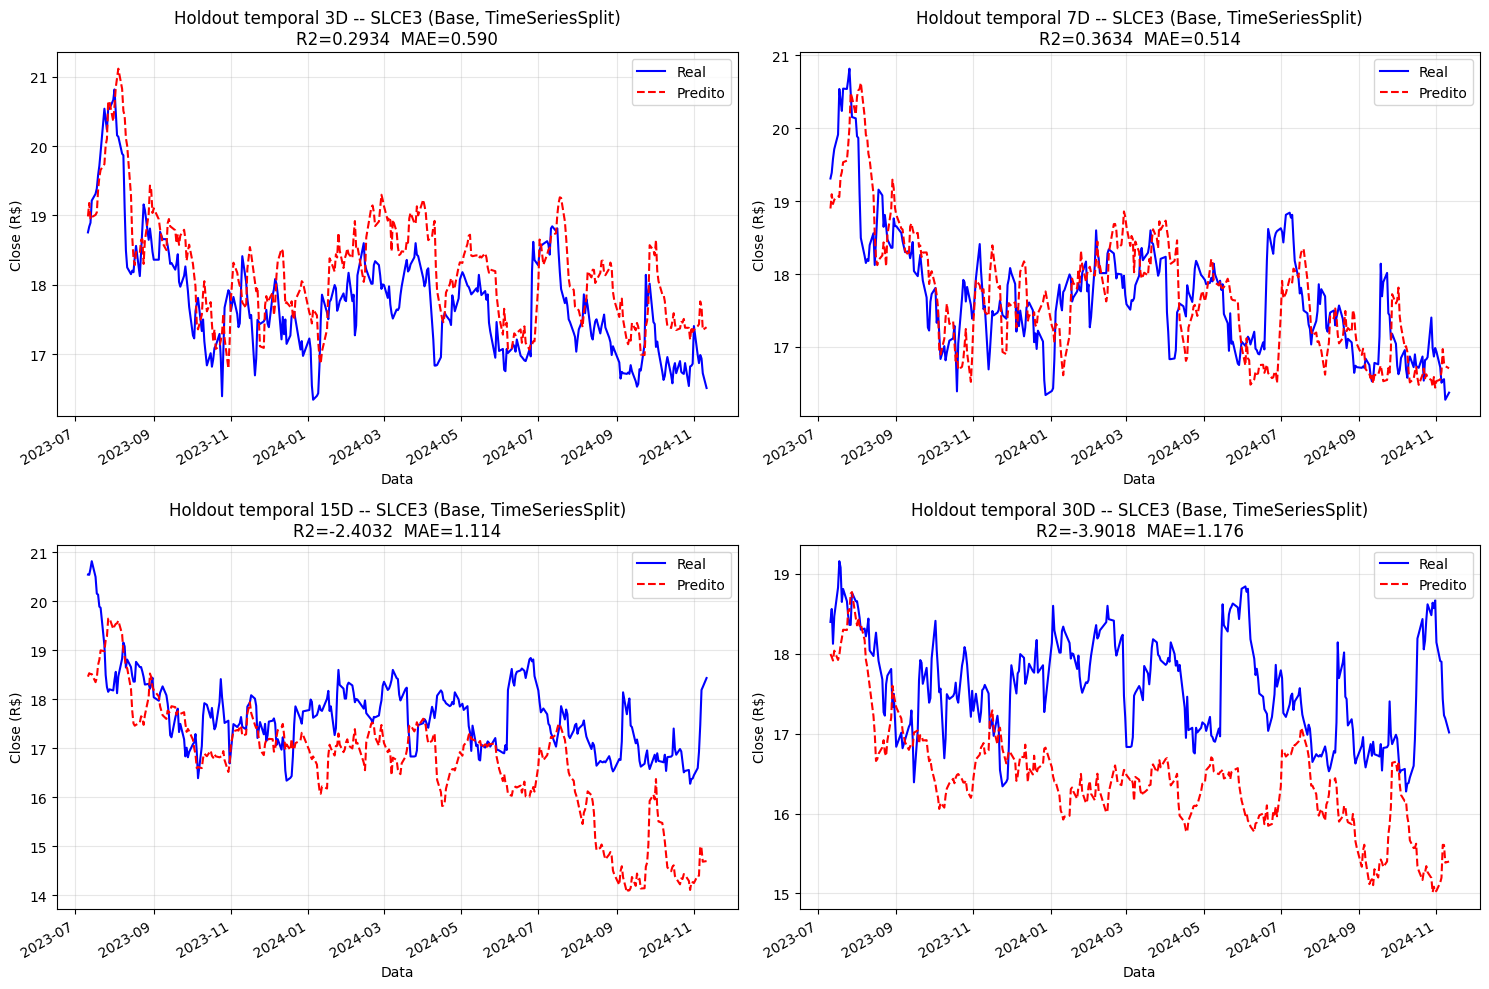

In [5]:
# Grafico: serie temporal real vs predito (todos os 4 horizontes)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for idx, period in enumerate(['3d', '7d', '15d', '30d']):
    r = results[period]
    ax = axes[idx]
    ax.plot(r['X_test'].index, r['y_test'].values, 'b-', label='Real', linewidth=1.5)
    ax.plot(r['X_test'].index, r['y_pred'], 'r--', label='Predito', linewidth=1.5)
    ax.set_title(f'Holdout temporal {period.upper()} -- SLCE3 (Base, TimeSeriesSplit)\nR2={r["test_r2"]:.4f}  MAE={r["test_mae"]:.3f}')
    ax.set_xlabel('Data')
    ax.set_ylabel('Close (R$)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'serie_temporal_{company_lower}_{DATASET_LABEL}.png', dpi=200, bbox_inches='tight')
plt.show()

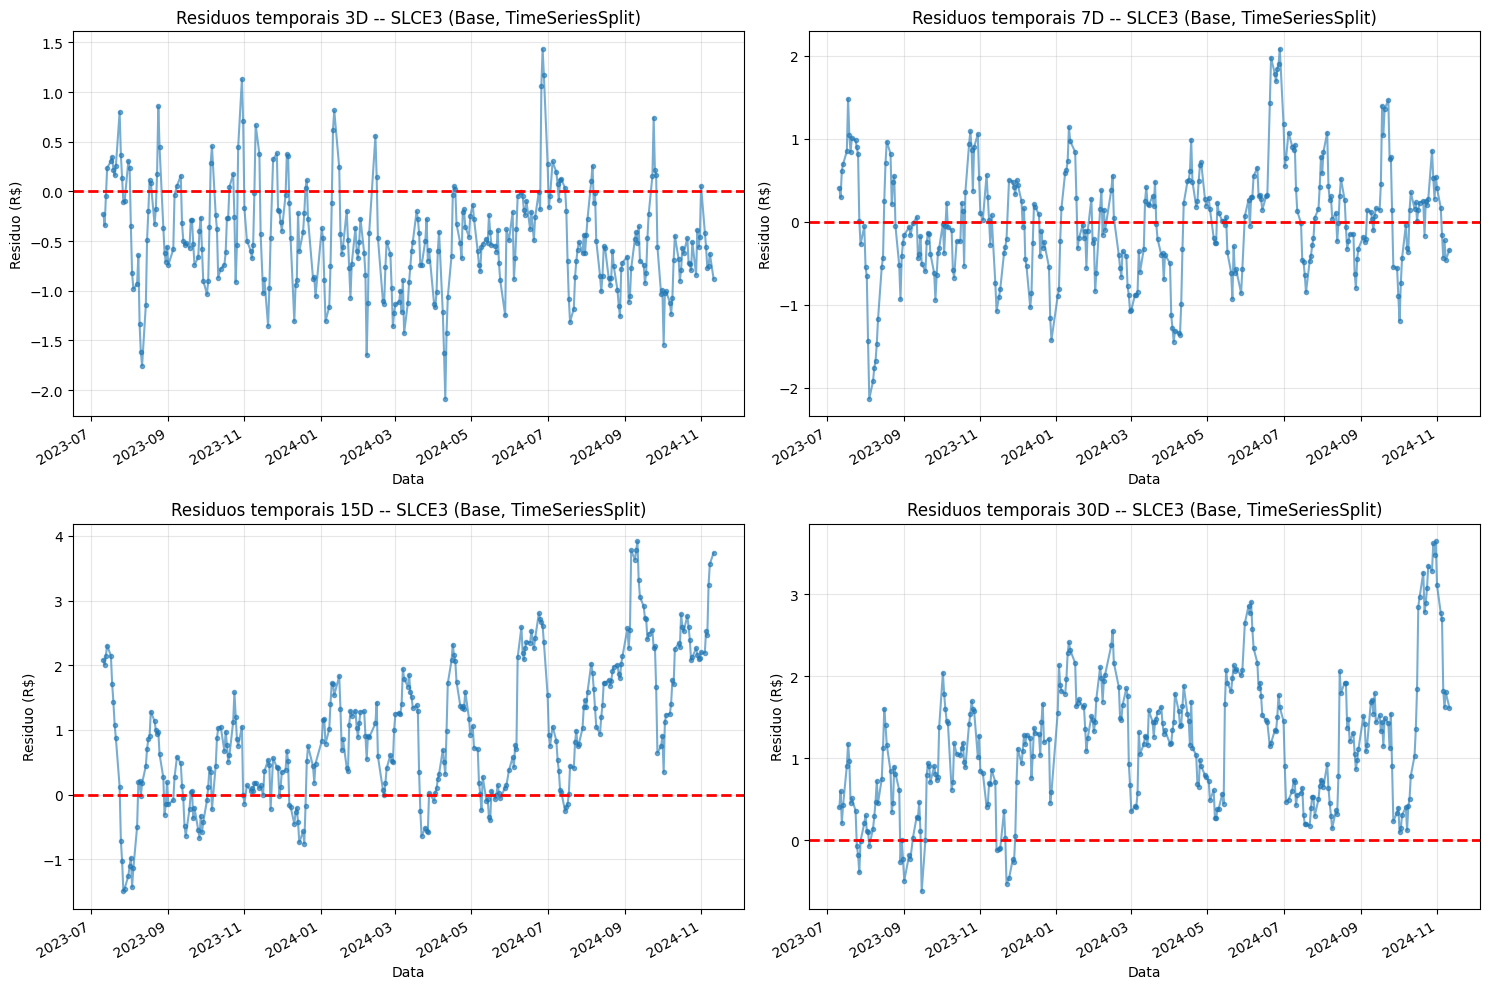

In [6]:
# Grafico: residuos temporais (avalia heterocedasticidade no horizonte temporal)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for idx, period in enumerate(['3d', '7d', '15d', '30d']):
    r = results[period]
    residuos = r['y_test'].values - r['y_pred']
    ax = axes[idx]
    ax.plot(r['X_test'].index, residuos, 'o-', markersize=3, alpha=0.6)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Residuos temporais {period.upper()} -- SLCE3 (Base, TimeSeriesSplit)')
    ax.set_xlabel('Data')
    ax.set_ylabel('Residuo (R$)')
    ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'residuos_temporais_{company_lower}_{DATASET_LABEL}.png', dpi=200, bbox_inches='tight')
plt.show()